In [ ]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torchvision.utils as vutils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.manual_seed(42)
np.random.seed(42)

Device: cpu


In [ ]:
url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/birthday%20cake.npy"
path = "birthday cake.npy"

if not os.path.exists(path):
    urllib.request.urlretrieve(url, path)
    print("Downloaded birthday cake.npy")
else:
    print("birthday cake.npy already exists")

Downloaded birthday cake.npy


In [ ]:
# Loading the QuickDraw birthday cake dataset
bday_cakes = np.load(path)

print("Original dataset shape:", bday_cakes.shape)
num_samples = 50000
bday_cakes = bday_cakes[:num_samples]

print("Subset shape:", bday_cakes.shape)

Original dataset shape: (144982, 784)
Subset shape: (50000, 784)


In [ ]:
# Reshape flattened vectors into 28x28 grayscale images
bday_cakes = bday_cakes.reshape(-1, 1, 28, 28).astype(np.float32)

bday_cakes = (bday_cakes / 127.5) - 1.0
bday_tensor = torch.tensor(bday_cakes)
print("Tensor shape:", bday_tensor.shape)

Tensor shape: torch.Size([50000, 1, 28, 28])


In [ ]:
batch_size = 128

bday_loader = DataLoader(
    TensorDataset(bday_tensor),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

print("No of batches:", len(bday_loader))

No of batches: 390


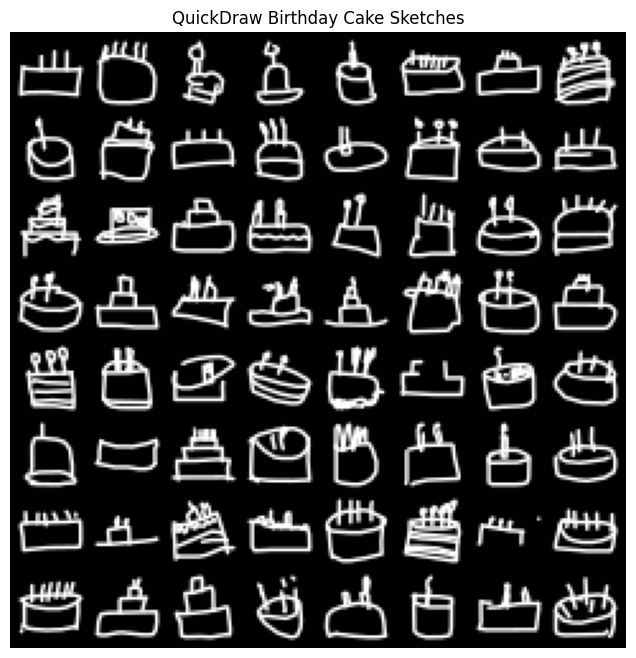

In [ ]:
real_batch = next(iter(bday_loader))[0]

# Converting images from [-1, 1] back to [0, 1] for display
real_dis = (real_batch[:64] + 1) / 2

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("QuickDraw Birthday Cake Sketches")

plt.imshow(np.transpose(vutils.make_grid( real_dis, nrow=8, padding=2, normalize=False).numpy(), (1, 2, 0)), cmap="gray")
plt.savefig("real_birthday_cakes.png")
plt.show()

In [ ]:
z_dim = 100
image_channels = 1

class BirthdayCakeGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            # Input: (100, 1, 1)
            nn.ConvTranspose2d(z_dim, 128, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            # Output: (128, 7, 7) -> (64, 14, 14)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # Output: (64, 14, 14) -> (1, 28, 28)
            nn.ConvTranspose2d(64, image_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise):
        return self.model(noise)


class BirthdayCakeDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            # Input: (1, 28, 28)
            nn.Conv2d(image_channels, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # Output: (64, 14, 14) -> (128, 7, 7)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, images):
        return self.model(images)

Epoch 01/20 | Dis Loss: 0.7746 | Gen Loss: 1.4767
Epoch 02/20 | Dis Loss: 0.4746 | Gen Loss: 2.3676
Epoch 03/20 | Dis Loss: 0.4598 | Gen Loss: 2.6164
Epoch 04/20 | Dis Loss: 0.4587 | Gen Loss: 2.7032
Epoch 05/20 | Dis Loss: 0.4503 | Gen Loss: 2.7929
Epoch 06/20 | Dis Loss: 0.4490 | Gen Loss: 2.8558
Epoch 07/20 | Dis Loss: 0.4430 | Gen Loss: 2.9063
Epoch 08/20 | Dis Loss: 0.4391 | Gen Loss: 2.9763
Epoch 09/20 | Dis Loss: 0.4381 | Gen Loss: 3.0159
Epoch 10/20 | Dis Loss: 0.4341 | Gen Loss: 3.0743
Epoch 11/20 | Dis Loss: 0.4302 | Gen Loss: 3.1147
Epoch 12/20 | Dis Loss: 0.4290 | Gen Loss: 3.1455
Epoch 13/20 | Dis Loss: 0.4266 | Gen Loss: 3.2094
Epoch 14/20 | Dis Loss: 0.4239 | Gen Loss: 3.2502
Epoch 15/20 | Dis Loss: 0.4189 | Gen Loss: 3.2798
Epoch 16/20 | Dis Loss: 0.4241 | Gen Loss: 3.2748
Epoch 17/20 | Dis Loss: 0.4218 | Gen Loss: 3.2685
Epoch 18/20 | Dis Loss: 0.4228 | Gen Loss: 3.3018
Epoch 19/20 | Dis Loss: 0.4205 | Gen Loss: 3.3390
Epoch 20/20 | Dis Loss: 0.4163 | Gen Loss: 3.3649


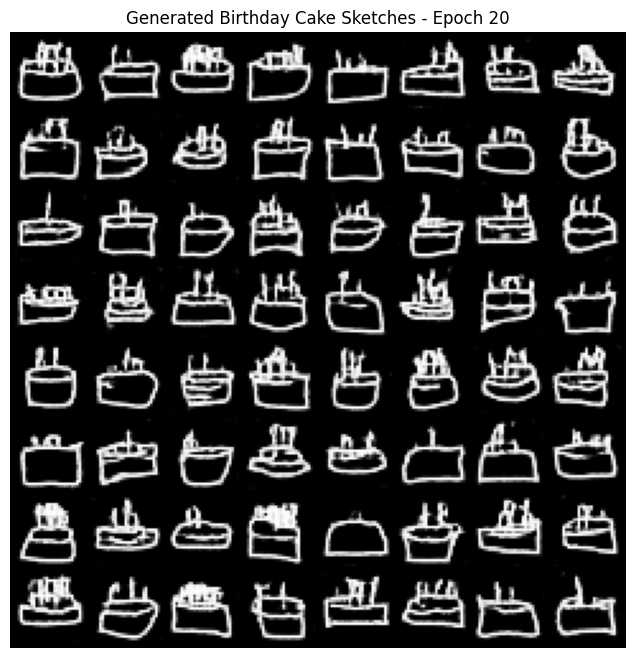

<Figure size 640x480 with 0 Axes>

In [ ]:
# Move models to the selected device
generator = BirthdayCakeGenerator().to(device)
discriminator = BirthdayCakeDiscriminator().to(device)

# Loss function
Loss = nn.BCELoss()

# Optimisers
generator_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

num_epochs = 20

generator_losses = []
discriminator_losses = []

for epoch in range(num_epochs):
    epoch_g_loss = 0
    epoch_d_loss = 0

    for (real_images,) in bday_loader:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.full((batch_size, 1), 0.9, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # Training the Discriminator
        noise = torch.randn(batch_size, z_dim, 1, 1, device=device)
        fake_images = generator(noise)

        real_predictions = discriminator(real_images)
        fake_predictions = discriminator(fake_images.detach())

        real_loss = Loss(real_predictions, real_labels)
        fake_loss = Loss(fake_predictions, fake_labels)

        discriminator_loss = real_loss + fake_loss

        discriminator_optimizer.zero_grad()
        discriminator_loss.backward()
        discriminator_optimizer.step()

        # Training the Generator
        noise = torch.randn(batch_size, z_dim, 1, 1, device=device)

        generated_images = generator(noise)

        generator_loss = Loss(
            discriminator(generated_images),
            real_labels
        )

        generator_optimizer.zero_grad()
        generator_loss.backward()
        generator_optimizer.step()

        epoch_g_loss += generator_loss.item()
        epoch_d_loss += discriminator_loss.item()

    generator_losses.append(epoch_g_loss / len(bday_loader))
    discriminator_losses.append(epoch_d_loss / len(bday_loader))

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Dis Loss: {discriminator_losses[-1]:.4f} | "
        f"Gen Loss: {generator_losses[-1]:.4f}"
    )

    # Display generated sketches every 10 epochs
    if (epoch + 1) % 20 == 0:
        generator.eval()
        with torch.no_grad():

            noise = torch.randn(64, z_dim, 1, 1, device=device)
            generated_images = generator(noise).cpu()

        generated_images = (generated_images + 1) / 2

        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title(f"Generated Birthday Cake Sketches - Epoch {epoch + 1}")
        plt.imshow(np.transpose(vutils.make_grid(generated_images, nrow=8, padding=2).numpy(),(1, 2, 0)),cmap="gray")
        plt.show()
        plt.savefig(f"generated_birthday_cakes_epoch_{epoch + 1}.png")
        generator.train()

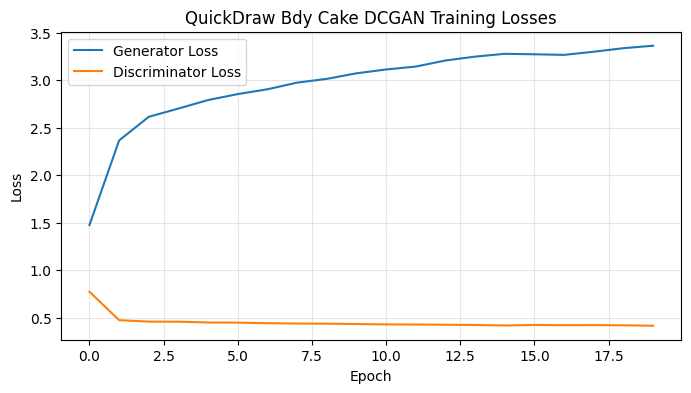

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")
plt.title("QuickDraw Bdy Cake DCGAN Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("bday_cake_losses.png")
plt.show()

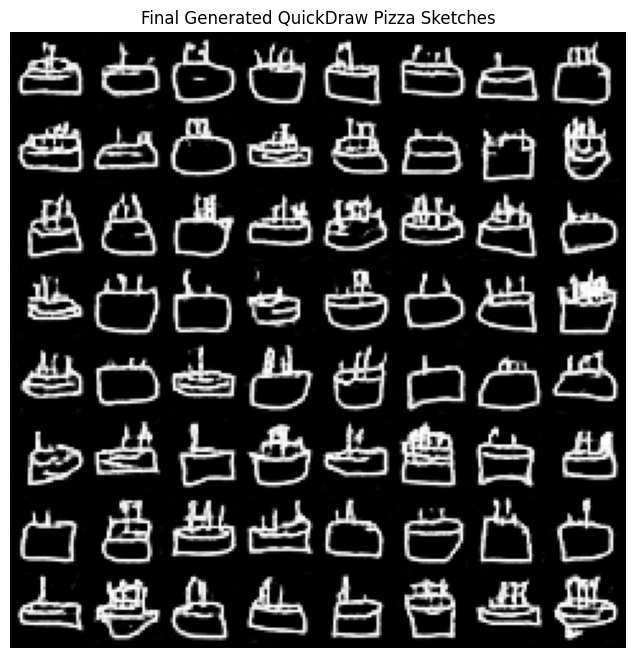

In [ ]:
generator.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim, 1, 1).to(device)
    fake_pizza = generator(z).cpu()

fake_dis = (fake_pizza + 1) / 2

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Final Generated QuickDraw Pizza Sketches")
plt.imshow(np.transpose(vutils.make_grid(fake_dis, nrow=8, padding=2).numpy(), (1, 2, 0)),cmap="gray")
plt.savefig("final_generated_birthday_cakes.png")
plt.show()

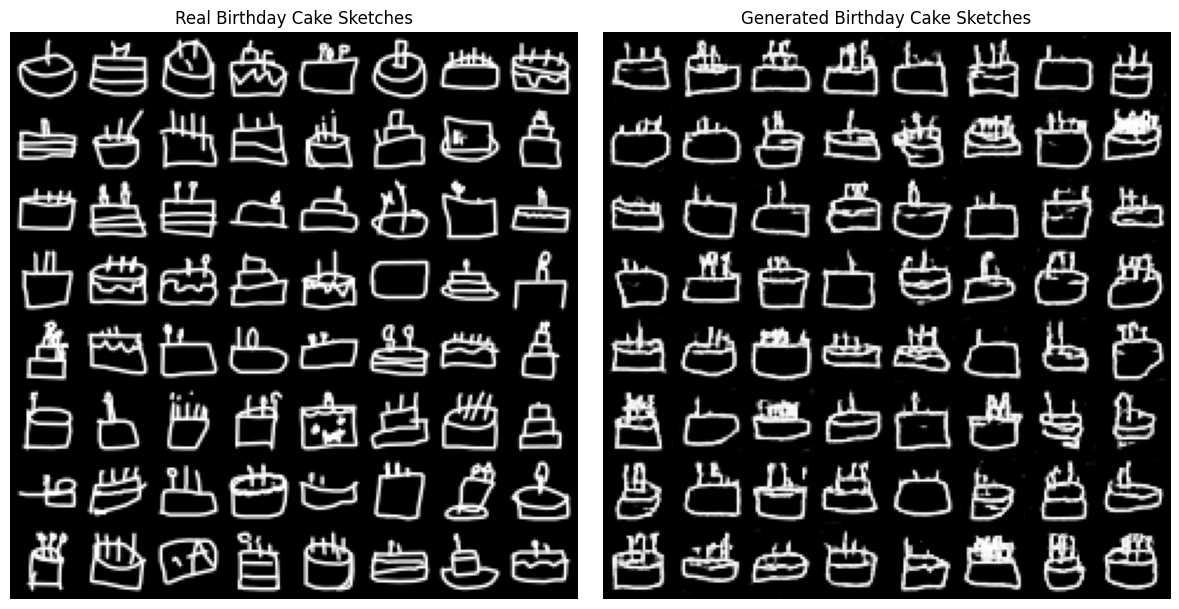

BirthdayCakeGenerator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)

<Figure size 640x480 with 0 Axes>

In [ ]:
real_images = next(iter(bday_loader))[0]
real_images = (real_images[:64] + 1) / 2

generator.eval()

with torch.no_grad():
    noise = torch.randn(64, z_dim, 1, 1, device=device)
    generated_images = generator(noise).cpu()

generated_images = (generated_images + 1) / 2

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(np.transpose(vutils.make_grid(real_images, nrow=8, padding=2).numpy(), (1, 2, 0)), cmap="gray")
plt.title("Real Birthday Cake Sketches")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.transpose(vutils.make_grid(generated_images, nrow=8, padding=2).numpy(), (1, 2, 0)), cmap="gray")
plt.title("Generated Birthday Cake Sketches")
plt.axis("off")
plt.tight_layout()
plt.show()
plt.savefig("real_vs_generated_birthday_cakes.png")
generator.train()

In [ ]:
real_batches = []
generated_batches = []

generator.eval()

with torch.no_grad():

    for batch_index, (real_images,) in enumerate(bday_loader):

        real_images = real_images.to(device)

        noise = torch.randn(real_images.size(0), z_dim, 1, 1, device=device)
        generated_images = generator(noise)

        real_batches.append(real_images.cpu())
        generated_batches.append(generated_images.cpu())
        if batch_index >= 10:
            break

real_images = torch.cat(real_batches, dim=0)
generated_images = torch.cat(generated_batches, dim=0)

avg_real = real_images.mean(dim=0)
avg_generated = generated_images.mean(dim=0)
mad = torch.abs(avg_real - avg_generated).mean().item()
print(f"Mean Absolute Difference (MAD): {mad:.4f}")

Mean Absolute Difference (MAD): 0.0517


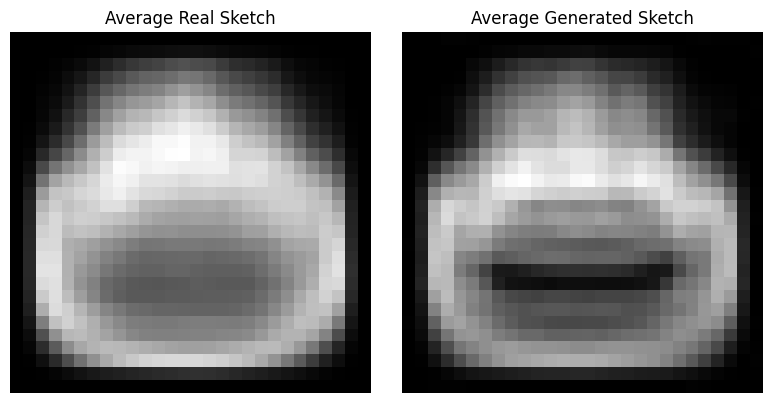

In [ ]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(((avg_real.squeeze() + 1) / 2), cmap="gray")
plt.title("Average Real Sketch")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(((avg_generated.squeeze() + 1) / 2), cmap="gray")
plt.title("Average Generated Sketch")
plt.axis("off")

plt.tight_layout()
plt.savefig("average_real_vs_generated_birthday_cakes.png")
plt.show()

In [ ]:
!pip install torchmetrics[image] torch-fidelity -q

In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance

fid = FrechetInceptionDistance(feature=768).to(device)
generator.eval()
eval_batches = 10

with torch.no_grad():

    for batch_index, (real_images,) in enumerate(bday_loader):

        real_images = real_images.to(device)

        noise = torch.randn(real_images.size(0), z_dim, 1, 1, device=device)
        generated_images = generator(noise)

        real_images = ((real_images + 1) * 127.5).clamp(0, 255).to(torch.uint8)
        generated_images = ((generated_images + 1) * 127.5).clamp(0, 255).to(torch.uint8)

        real_images = real_images.repeat(1, 3, 1, 1)
        generated_images = generated_images.repeat(1, 3, 1, 1)

        fid.update(real_images, real=True)
        fid.update(generated_images, real=False)

        if batch_index + 1 >= eval_batches:
            break

fid_value = fid.compute().item()

print(f"Birthday Cake FID Score: {fid_value:.4f}")

Birthday Cake FID Score: 0.1586


In [ ]:
url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/house.npy"
file_path = "house.npy"

if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)
    print("Downloaded house.npy")
else:
    print("house.npy already exists")

Downloaded house.npy


In [ ]:
house = np.load(file_path)

print("Dataset shape:", house.shape)

house = house[:50000]

house = house.reshape(-1, 1, 28, 28).astype(np.float32)
house = (house / 127.5) - 1.0

house_tensor = torch.tensor(house)

house_loader = DataLoader(
    TensorDataset(house_tensor),
    batch_size=128,
    shuffle=True,
    drop_last=True
)

print("Training tensor shape:", house_tensor.shape)

Dataset shape: (135420, 784)
Training tensor shape: torch.Size([50000, 1, 28, 28])


Epoch 01/20 | Dis Loss: 0.6837 | Gen Loss: 1.6602
Epoch 02/20 | Dis Loss: 0.4397 | Gen Loss: 2.6077
Epoch 03/20 | Dis Loss: 0.4170 | Gen Loss: 2.9702
Epoch 04/20 | Dis Loss: 0.4164 | Gen Loss: 3.1054
Epoch 05/20 | Dis Loss: 0.4178 | Gen Loss: 3.1458
Epoch 06/20 | Dis Loss: 0.4203 | Gen Loss: 3.1604
Epoch 07/20 | Dis Loss: 0.4244 | Gen Loss: 3.1558
Epoch 08/20 | Dis Loss: 0.4262 | Gen Loss: 3.1840
Epoch 09/20 | Dis Loss: 0.4203 | Gen Loss: 3.2261
Epoch 10/20 | Dis Loss: 0.4199 | Gen Loss: 3.2691
Epoch 11/20 | Dis Loss: 0.4207 | Gen Loss: 3.3028
Epoch 12/20 | Dis Loss: 0.4163 | Gen Loss: 3.3390
Epoch 13/20 | Dis Loss: 0.4126 | Gen Loss: 3.3860
Epoch 14/20 | Dis Loss: 0.4176 | Gen Loss: 3.3987
Epoch 15/20 | Dis Loss: 0.4145 | Gen Loss: 3.4108
Epoch 16/20 | Dis Loss: 0.4121 | Gen Loss: 3.4252
Epoch 17/20 | Dis Loss: 0.4084 | Gen Loss: 3.4703
Epoch 18/20 | Dis Loss: 0.4573 | Gen Loss: 3.2637
Epoch 19/20 | Dis Loss: 0.4045 | Gen Loss: 3.4742
Epoch 20/20 | Dis Loss: 0.4016 | Gen Loss: 3.5364


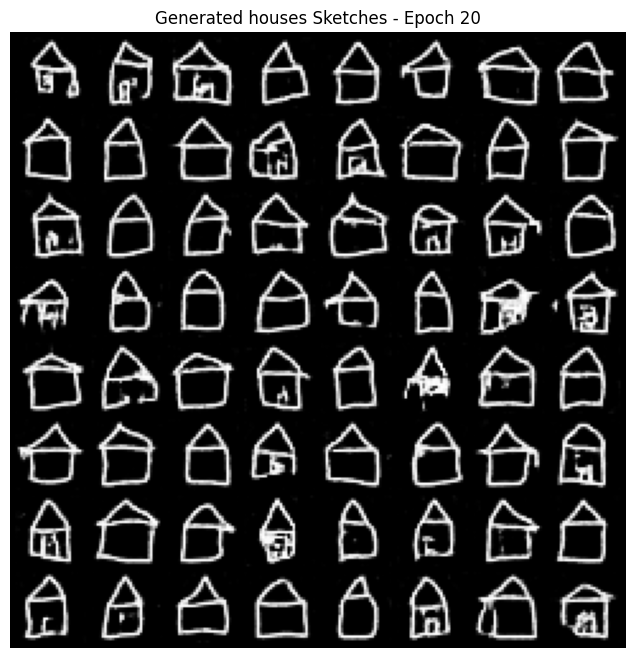

<Figure size 640x480 with 0 Axes>

In [ ]:
# Move models to the selected device
generator = BirthdayCakeGenerator().to(device)
discriminator = BirthdayCakeDiscriminator().to(device)

# Loss function
Loss = nn.BCELoss()

# Optimisers
generator_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

num_epochs = 20

generator_losses = []
discriminator_losses = []

for epoch in range(num_epochs):
    epoch_g_loss = 0
    epoch_d_loss = 0

    for (real_images,) in house_loader:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.full((batch_size, 1), 0.9, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # Training the Discriminator
        noise = torch.randn(batch_size, z_dim, 1, 1, device=device)
        fake_images = generator(noise)

        real_predictions = discriminator(real_images)
        fake_predictions = discriminator(fake_images.detach())

        real_loss = Loss(real_predictions, real_labels)
        fake_loss = Loss(fake_predictions, fake_labels)

        discriminator_loss = real_loss + fake_loss

        discriminator_optimizer.zero_grad()
        discriminator_loss.backward()
        discriminator_optimizer.step()

        # Training the Generator
        noise = torch.randn(batch_size, z_dim, 1, 1, device=device)

        generated_images = generator(noise)

        generator_loss = Loss(
            discriminator(generated_images),
            real_labels
        )

        generator_optimizer.zero_grad()
        generator_loss.backward()
        generator_optimizer.step()

        epoch_g_loss += generator_loss.item()
        epoch_d_loss += discriminator_loss.item()

    generator_losses.append(epoch_g_loss / len(bday_loader))
    discriminator_losses.append(epoch_d_loss / len(bday_loader))

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Dis Loss: {discriminator_losses[-1]:.4f} | "
        f"Gen Loss: {generator_losses[-1]:.4f}"
    )

    # Display generated sketches every 10 epochs
    if (epoch + 1) % 20 == 0:
        generator.eval()
        with torch.no_grad():

            noise = torch.randn(64, z_dim, 1, 1, device=device)
            generated_images = generator(noise).cpu()

        generated_images = (generated_images + 1) / 2

        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title(f"Generated houses Sketches - Epoch {epoch + 1}")
        plt.imshow(np.transpose(vutils.make_grid(generated_images, nrow=8, padding=2).numpy(),(1, 2, 0)),cmap="gray")
        plt.show()
        plt.savefig(f"generated_house_epoch_{epoch + 1}.png")
        generator.train()

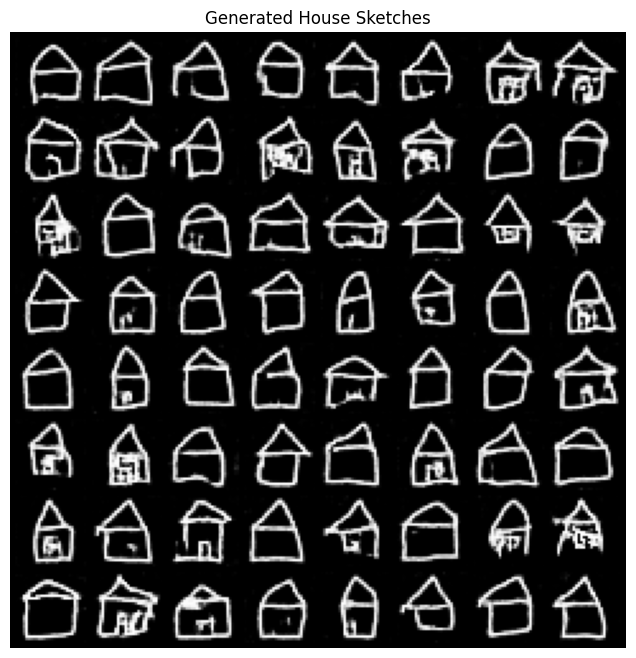

In [ ]:
generator.eval()

with torch.no_grad():
    noise = torch.randn(64, z_dim, 1, 1).to(device)
    generated_images = generator(noise).cpu()

generated_images = (generated_images + 1) / 2

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated House Sketches")

plt.imshow(
    np.transpose(
        vutils.make_grid(generated_images, nrow=8, padding=2).numpy(),
        (1, 2, 0)
    ),
    cmap="gray"
)

plt.show()

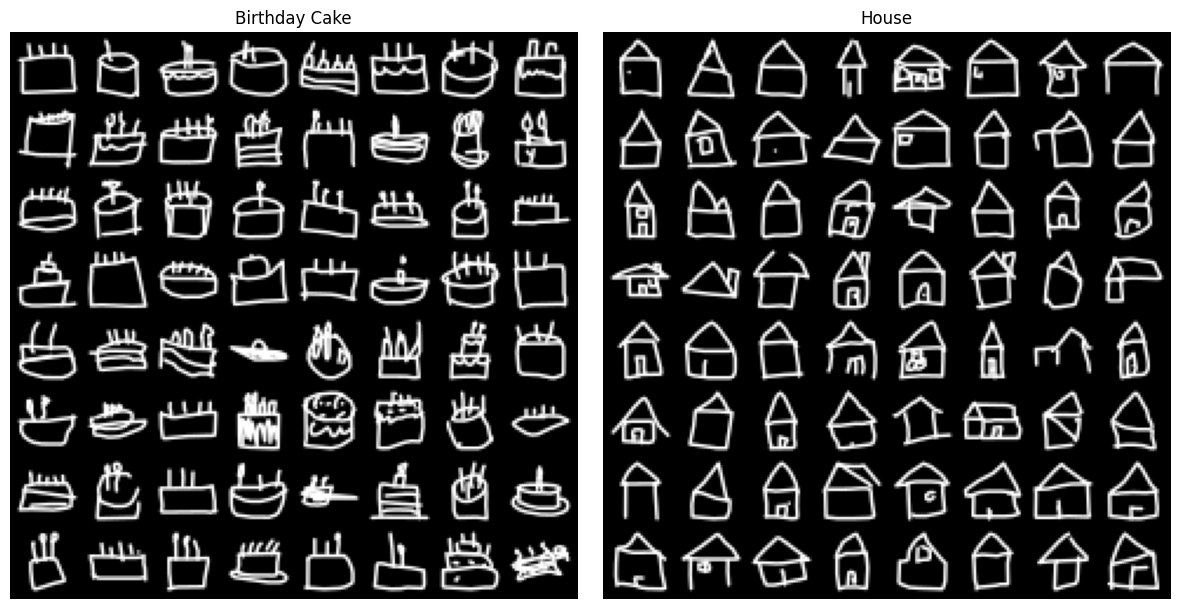

In [ ]:
cake_batch = next(iter(bday_loader))[0]
house_batch = next(iter(house_loader))[0]

cake_display = (cake_batch[:64] + 1) / 2
house_display = (house_batch[:64] + 1) / 2

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(
    np.transpose(vutils.make_grid(cake_display, nrow=8).numpy(), (1, 2, 0)),
    cmap="gray"
)
plt.title("Birthday Cake")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    np.transpose(vutils.make_grid(house_display, nrow=8).numpy(), (1, 2, 0)),
    cmap="gray"
)
plt.title("House")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
real_batches = []
generated_batches = []

generator.eval()

with torch.no_grad():

    for batch_index, (real_images,) in enumerate(bday_loader):

        real_images = real_images.to(device)

        noise = torch.randn(real_images.size(0), z_dim, 1, 1, device=device)
        generated_images = generator(noise)

        real_batches.append(real_images.cpu())
        generated_batches.append(generated_images.cpu())
        if batch_index >= 10:
            break

real_images = torch.cat(real_batches, dim=0)
generated_images = torch.cat(generated_batches, dim=0)

avg_real = real_images.mean(dim=0)
avg_generated = generated_images.mean(dim=0)
mad = torch.abs(avg_real - avg_generated).mean().item()
print(f"Mean Absolute Difference (MAD): {mad:.4f}")

Mean Absolute Difference (MAD): 0.1509
